In [22]:
# Find relationships between items customers frequently buy together.
# Example : If a customer buys bread and butter, they’re likely to also buy milk."
# This script uses the Apriori algorithm to identify frequent itemsets and generate association rules.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from mlxtend.frequent_patterns import apriori, association_rules

In [24]:
df = pd.read_csv("C:\\Users\\hp\\Downloads\\Assignment-1_Data.csv.zip", on_bad_lines='skip')
df.head()

,BillNo;Itemname;Quantity;Date;Price;CustomerID;Country
536365;WHITE HANGING HEART T-LIGHT HOLDER;6;01.12.2010 08:26;2,55;17850;United Kingdom
536365;WHITE METAL LANTERN;6;01.12.2010 08:26;3,39;17850;United Kingdom
536365;CREAM CUPID HEARTS COAT HANGER;8;01.12.2010 08:26;2,75;17850;United Kingdom
536365;KNITTED UNION FLAG HOT WATER BOTTLE;6;01.12.2010 08:26;3,39;17850;United Kingdom
536365;RED WOOLLY HOTTIE WHITE HEART.;6;01.12.2010 08:26;3,39;17850;United Kingdom


In [25]:
print(df.head())


                                                   BillNo;Itemname;Quantity;Date;Price;CustomerID;Country
536365;WHITE HANGING HEART T-LIGHT HOLDER;6;01....                            55;17850;United Kingdom    
536365;WHITE METAL LANTERN;6;01.12.2010 08:26;3                               39;17850;United Kingdom    
536365;CREAM CUPID HEARTS COAT HANGER;8;01.12.2...                            75;17850;United Kingdom    
536365;KNITTED UNION FLAG HOT WATER BOTTLE;6;01...                            39;17850;United Kingdom    
536365;RED WOOLLY HOTTIE WHITE HEART.;6;01.12.2...                            39;17850;United Kingdom    


In [26]:
print(df.head(10))


                                                   BillNo;Itemname;Quantity;Date;Price;CustomerID;Country
536365;WHITE HANGING HEART T-LIGHT HOLDER;6;01....                            55;17850;United Kingdom    
536365;WHITE METAL LANTERN;6;01.12.2010 08:26;3                               39;17850;United Kingdom    
536365;CREAM CUPID HEARTS COAT HANGER;8;01.12.2...                            75;17850;United Kingdom    
536365;KNITTED UNION FLAG HOT WATER BOTTLE;6;01...                            39;17850;United Kingdom    
536365;RED WOOLLY HOTTIE WHITE HEART.;6;01.12.2...                            39;17850;United Kingdom    
536365;SET 7 BABUSHKA NESTING BOXES;2;01.12.201...                            65;17850;United Kingdom    
536365;GLASS STAR FROSTED T-LIGHT HOLDER;6;01.1...                            25;17850;United Kingdom    
536366;HAND WARMER UNION JACK;6;01.12.2010 08:28;1                            85;17850;United Kingdom    
536366;HAND WARMER RED POLKA DOT;6;01.12.2010 

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517426 entries, 536365;WHITE HANGING HEART T-LIGHT HOLDER;6;01.12.2010 08:26;2 to 581587;BAKING SET 9 PIECE RETROSPOT;3;09.12.2011 12:50;4
Data columns (total 1 columns):
 #   Column                                                  Non-Null Count   Dtype 
---  ------                                                  --------------   ----- 
 0   BillNo;Itemname;Quantity;Date;Price;CustomerID;Country  513277 non-null  object
dtypes: object(1)
memory usage: 7.9+ MB


In [28]:
df.isnull().sum().sort_values(ascending=False)

BillNo;Itemname;Quantity;Date;Price;CustomerID;Country    4149
dtype: int64

In [29]:
df.isnull().sum()

BillNo;Itemname;Quantity;Date;Price;CustomerID;Country    4149
dtype: int64

In [30]:
print(df.columns.tolist())


['BillNo;Itemname;Quantity;Date;Price;CustomerID;Country']


In [31]:
df.columns = df.columns.str.strip()


In [32]:
import pandas as pd

df = pd.read_csv(
    "C:\\Users\\hp\\Downloads\\Assignment-1_Data.csv.zip",
    sep=';',          # your file uses semicolon separator
    engine='python'   # handles mixed characters better
)

print(df.columns.tolist())  # verify columns


['BillNo', 'Itemname', 'Quantity', 'Date', 'Price', 'CustomerID', 'Country']


In [33]:
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   BillNo      522064 non-null  object        
 1   Itemname    520609 non-null  object        
 2   Quantity    522064 non-null  int64         
 3   Date        522064 non-null  datetime64[ns]
 4   Price       522064 non-null  object        
 5   CustomerID  388023 non-null  float64       
 6   Country     522064 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 27.9+ MB


In [34]:
df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,"2,55",17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,"3,39",17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,"2,75",17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,"3,39",17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,"3,39",17850.0,United Kingdom


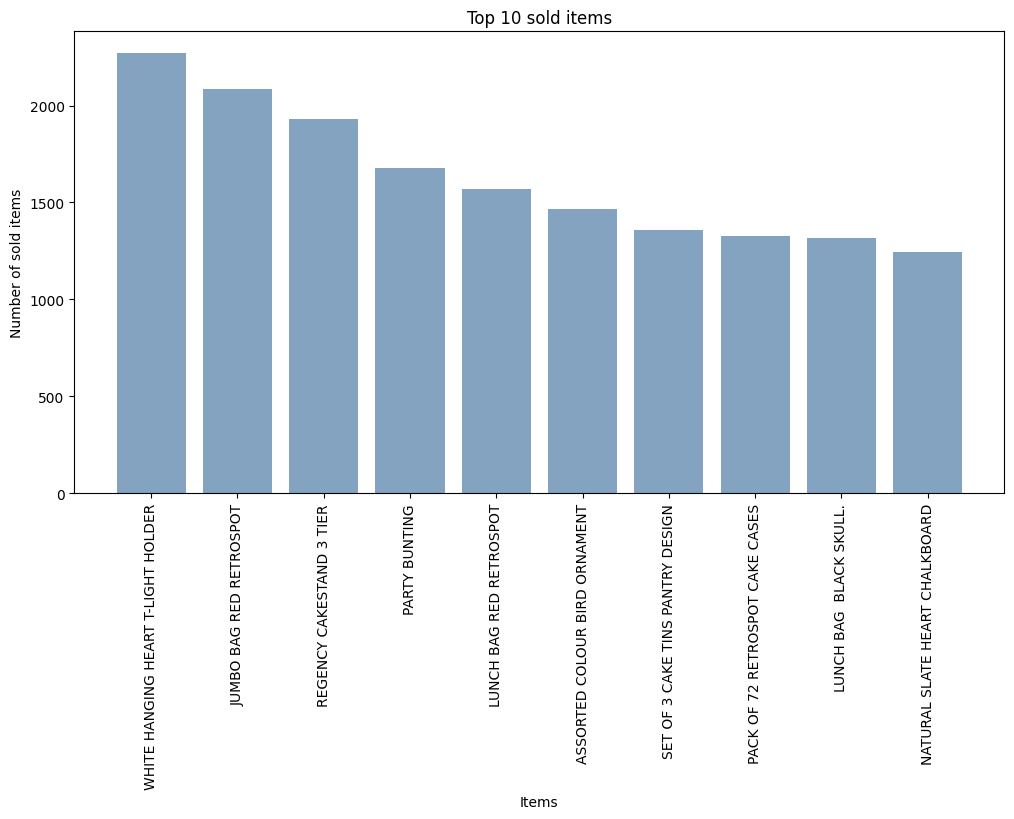

In [35]:
#
item_distr = df.groupby(by = "Itemname").size().reset_index(name = 'Frequency').sort_values(by = 'Frequency' , ascending = False).head(10)
bars = item_distr['Itemname']
heights = item_distr['Frequency']
x_pos = np.arange(len(bars))
plt.figure(figsize=(12,6))
plt.bar(x_pos, heights, color= (0.2, 0.4, 0.6, 0.6))
plt.title("Top 10 sold items")
plt.xlabel("Items")
plt.ylabel("Number of sold items")
plt.xticks(x_pos, bars, rotation=90)
plt.show()

In [36]:
df_date = df.set_index('Date')
df_date



,BillNo,Itemname,Quantity,Price,CustomerID,Country
Date,,,,,,
2010-12-01 08:26:00,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,"2,55",17850.0,United Kingdom
2010-12-01 08:26:00,536365,WHITE METAL LANTERN,6,"3,39",17850.0,United Kingdom
2010-12-01 08:26:00,536365,CREAM CUPID HEARTS COAT HANGER,8,"2,75",17850.0,United Kingdom
2010-12-01 08:26:00,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,"3,39",17850.0,United Kingdom
2010-12-01 08:26:00,536365,RED WOOLLY HOTTIE WHITE HEART.,6,"3,39",17850.0,United Kingdom
...,...,...,...,...,...,...
2011-12-09 12:50:00,581587,PACK OF 20 SPACEBOY NAPKINS,12,"0,85",12680.0,France
2011-12-09 12:50:00,581587,CHILDREN'S APRON DOLLY GIRL,6,"2,1",12680.0,France
2011-12-09 12:50:00,581587,CHILDRENS CUTLERY DOLLY GIRL,4,"4,15",12680.0,France


C:\Users\hp\AppData\Local\Temp\ipykernel_11532\1922567345.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_date.resample('M')["Itemname"].count().plot(figsize=(20,8),grid = True, title = "Number of item sold by month").set(xlabel = "Date", ylabel = "Number of items sold")


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Number of items sold')]

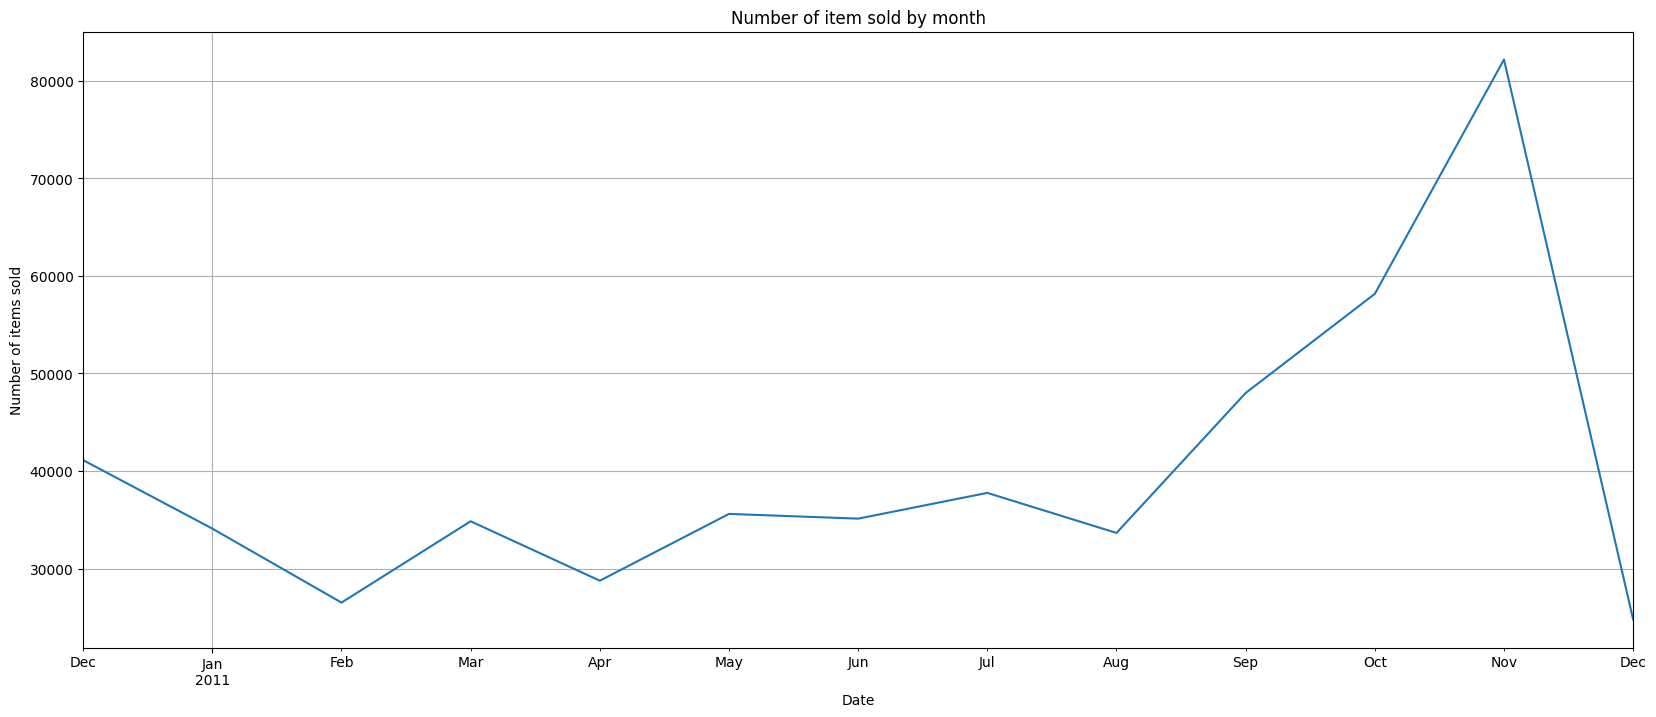

In [37]:
df_date.resample('M')["Itemname"].count().plot(figsize=(20,8),grid = True, title = "Number of item sold by month").set(xlabel = "Date", ylabel = "Number of items sold")


In [38]:
cust_level = df[['CustomerID', 'Itemname']].sort_values(by = 'CustomerID', ascending = False)
cust_level["Itemname"] = cust_level["Itemname"].str.strip()
cust_level

,CustomerID,Itemname
191784,18287.0,APPLE BATH SPONGE
191785,18287.0,STRAWBERRY BATH SPONGE
191786,18287.0,ICE CREAM SUNDAE LIP GLOSS
407402,18287.0,PAINTED METAL STAR WITH HOLLY BELLS
407401,18287.0,SET OF 3 WOODEN SLEIGH DECORATIONS
...,...,...
521695,NaN,JUMBO BAG RED RETROSPOT
521696,NaN,JUMBO BAG BAROQUE BLACK WHITE
521697,NaN,LADIES & GENTLEMEN METAL SIGN
521698,NaN,S/4 CACTI CANDLES


In [39]:
transaction = [a[1]["Itemname"].tolist() for a in list(cust_level.groupby(["CustomerID"]))]

In [40]:
from apyori import apriori
rules = apriori(transactions = transaction, min_support = 0.002,min_confidence = 0.05,min_lift =3 ,min_length=2)


In [41]:
# results = []
# for rule in rules:
#     results.append(rule)

import itertools
results = list(itertools.islice(rules, 100))  # first 100 items only



In [42]:
results


[RelationRecord(items=frozenset({'12 COLOURED PARTY BALLOONS', '10 COLOUR SPACEBOY PEN'}), support=0.003490807540144287, ordered_statistics=[OrderedStatistic(items_base=frozenset({'10 COLOUR SPACEBOY PEN'}), items_add=frozenset({'12 COLOURED PARTY BALLOONS'}), confidence=0.08522727272727272, lift=3.555549426301853), OrderedStatistic(items_base=frozenset({'12 COLOURED PARTY BALLOONS'}), items_add=frozenset({'10 COLOUR SPACEBOY PEN'}), confidence=0.14563106796116504, lift=3.555549426301853)]),
 RelationRecord(items=frozenset({'12 PENCIL SMALL TUBE WOODLAND', '10 COLOUR SPACEBOY PEN'}), support=0.0076797765883174305, ordered_statistics=[OrderedStatistic(items_base=frozenset({'10 COLOUR SPACEBOY PEN'}), items_add=frozenset({'12 PENCIL SMALL TUBE WOODLAND'}), confidence=0.18749999999999997, lift=4.240460526315789), OrderedStatistic(items_base=frozenset({'12 PENCIL SMALL TUBE WOODLAND'}), items_add=frozenset({'10 COLOUR SPACEBOY PEN'}), confidence=0.17368421052631577, lift=4.240460526315789)

In [44]:

def inspect(results):
    lhs = [tuple(result[2][0][0]) for result in results]
    rhs = [tuple(result[2][0][1]) for result in results]
    supports = [result[1] for result in results]
    confidences = [result[2][0][2] for result in results]
    lifts = [result[2][0][3] for result in results]
    return list(zip(lhs, rhs, supports, confidences, lifts))

result_in_dataframe = pd.DataFrame(inspect(results),
                                   columns=['Left Hand Side', 'Right Hand Side', 'Supports', 'Confidences', 'Lifts'])


In [45]:
result_in_dataframe.nlargest(n = 10, columns = 'Lifts')

,Left Hand Side,Right Hand Side,Supports,Confidences,Lifts
25,"(10 COLOUR SPACEBOY PEN,)","(ASSTD DESIGN RACING CAR PEN,)",0.003724,0.090909,9.300866
12,"(10 COLOUR SPACEBOY PEN,)","(3D SHEET OF DOG STICKERS,)",0.002327,0.056818,7.398416
11,"(10 COLOUR SPACEBOY PEN,)","(3D SHEET OF CAT STICKERS,)",0.002327,0.056818,6.975649
60,"(10 COLOUR SPACEBOY PEN,)","(CAMOUFLAGE LED TORCH,)",0.005585,0.136364,6.975649
57,"(10 COLOUR SPACEBOY PEN,)","(BUTTERFLIES STICKERS,)",0.002560,0.062500,6.245640
23,"(10 COLOUR SPACEBOY PEN,)","(ASSORTED CREEPY CRAWLIES,)",0.003491,0.085227,5.906800
98,"(10 COLOUR SPACEBOY PEN,)","(CHOCOLATE CALCULATOR,)",0.004422,0.107955,5.657081
41,"(10 COLOUR SPACEBOY PEN,)","(BLUE CALCULATOR RULER,)",0.002094,0.051136,5.493324
29,"(10 COLOUR SPACEBOY PEN,)","(BAKING MOULD ROSE MILK CHOCOLATE,)",0.002327,0.056818,5.425505
93,"(10 COLOUR SPACEBOY PEN,)","(CHILDS GARDEN RAKE PINK,)",0.002327,0.056818,5.194632
